# Task
Perform an Exploratory Data Analysis (EDA) on the `/content/season-0102.csv` file, including data loading, initial inspection, missing values analysis, visualization of distributions, correlation analysis, and summarization of key findings.

## Cargar Datos

### Subtask:
Cargar el archivo CSV '/content/season-0102.csv' en un DataFrame de pandas para iniciar el análisis.


**Reasoning**:
First, I'll import the pandas library, which is essential for working with DataFrames. Then, I'll load the specified CSV file into a pandas DataFrame named `df`.



In [1]:
import pandas as pd

df = pd.read_csv('/content/season-0102.csv')
df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,28/07/01,Cottbus,Hamburg,1,0,H,0,0,D,Franz-Xaver Wack,...,2,1,24,23,6,3,2,2,0,0
1,28/07/01,Dortmund,Nurnberg,2,0,H,1,0,H,Michael Weiner,...,10,1,15,17,5,4,2,2,0,0
2,28/07/01,Freiburg,Werder Bremen,3,0,H,0,0,D,Hartmut Strampe,...,5,3,11,12,9,5,1,4,0,1
3,28/07/01,Leverkusen,Wolfsburg,2,1,H,1,0,H,Hermann Albrecht,...,7,2,6,15,11,0,2,1,0,0
4,28/07/01,M'gladbach,Bayern Munich,1,0,H,1,0,H,Edgar Steinborn,...,4,3,19,25,5,7,0,4,0,0


## Inspección Inicial de Datos

### Subtask:
Mostrar las primeras filas del DataFrame, información general (tipos de datos, valores no nulos) y estadísticas descriptivas para obtener una comprensión inicial de los datos.


**Reasoning**:
To perform the initial data inspection, I will display the first 5 rows of the DataFrame, show a concise summary including data types and non-null values, and generate descriptive statistics for numerical columns.



In [2]:
print("Primeras 5 filas del DataFrame:")
print(df.head())

print("\nInformación general del DataFrame:")
df.info()

print("\nEstadísticas descriptivas del DataFrame:")
df.describe()

Primeras 5 filas del DataFrame:
       Date    HomeTeam       AwayTeam  FTHG  FTAG FTR  HTHG  HTAG HTR  \
0  28/07/01     Cottbus        Hamburg     1     0   H     0     0   D   
1  28/07/01    Dortmund       Nurnberg     2     0   H     1     0   H   
2  28/07/01    Freiburg  Werder Bremen     3     0   H     0     0   D   
3  28/07/01  Leverkusen      Wolfsburg     2     1   H     1     0   H   
4  28/07/01  M'gladbach  Bayern Munich     1     0   H     1     0   H   

             Referee  ...  HST  AST  HF  AF  HC  AC  HY  AY  HR  AR  
0  Franz-Xaver Wack   ...    2    1  24  23   6   3   2   2   0   0  
1    Michael Weiner   ...   10    1  15  17   5   4   2   2   0   0  
2   Hartmut Strampe   ...    5    3  11  12   9   5   1   4   0   1  
3  Hermann Albrecht   ...    7    2   6  15  11   0   2   1   0   0  
4   Edgar Steinborn   ...    4    3  19  25   5   7   0   4   0   0  

[5 rows x 22 columns]

Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeI

,FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
count,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000
mean,1.761438,1.156863,0.696078,0.509804,14.676471,10.026144,6.428105,4.303922,16.898693,18.300654,6.529412,4.202614,1.918301,2.349673,0.075163,0.150327
std,1.371352,1.176924,0.850719,0.716253,5.076132,4.113070,2.753786,2.310869,5.207768,4.976120,3.090034,2.649737,1.199669,1.339911,0.276223,0.375849
min,0.000000,0.000000,0.000000,0.000000,4.000000,2.000000,0.000000,0.000000,5.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,11.000000,7.000000,5.000000,3.000000,13.000000,15.000000,4.000000,2.000000,1.000000,1.000000,0.000000,0.000000
50%,2.000000,1.000000,0.000000,0.000000,15.000000,10.000000,6.000000,4.000000,16.000000,18.000000,6.000000,4.000000,2.000000,2.000000,0.000000,0.000000
75%,3.000000,2.000000,1.000000,1.000000,18.000000,13.000000,8.000000,6.000000,20.000000,22.000000,8.000000,6.000000,3.000000,3.000000,0.000000,0.000000
max,6.000000,5.000000,4.000000,3.000000,31.000000,25.000000,18.000000,15.000000,33.000000,34.000000,16.000000,15.000000,6.000000,8.000000,2.000000,2.000000


## Análisis de Valores Faltantes

### Subtask:
Identificar la presencia de valores faltantes en cada columna y visualizar su distribución para decidir la estrategia de manejo adecuada.


**Reasoning**:
To identify missing values, I will calculate the count and percentage of null values for each column in the DataFrame and display them.



In [3]:
missing_values_count = df.isnull().sum()
missing_values_percent = 100 * df.isnull().sum() / len(df)

missing_values_df = pd.DataFrame({
    'Missing Count': missing_values_count,
    'Missing Percentage': missing_values_percent
})

missing_values_df = missing_values_df[missing_values_df['Missing Count'] > 0]

if missing_values_df.empty:
    print("No hay valores faltantes en el DataFrame.")
else:
    print("Columnas con valores faltantes:")
    print(missing_values_df)

# Visualize missing values if any
if not missing_values_df.empty:
    import matplotlib.pyplot as plt
    import seaborn as sns
    plt.figure(figsize=(12, 6))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title('Distribución de Valores Faltantes')
    plt.show()

No hay valores faltantes en el DataFrame.


## Visualización de Distribuciones

### Subtask:
Crear visualizaciones como histogramas y diagramas de caja para variables numéricas, y gráficos de barras para variables categóricas. Se incluirán leyendas apropiadas en los gráficos para una mejor comprensión.


**Reasoning**:
To create the required visualizations, I will first import the necessary libraries, `matplotlib.pyplot` and `seaborn`. Then I will generate histograms and box plots for the specified numerical columns and bar plots for the categorical columns, ensuring each plot has appropriate labels and titles for clarity.



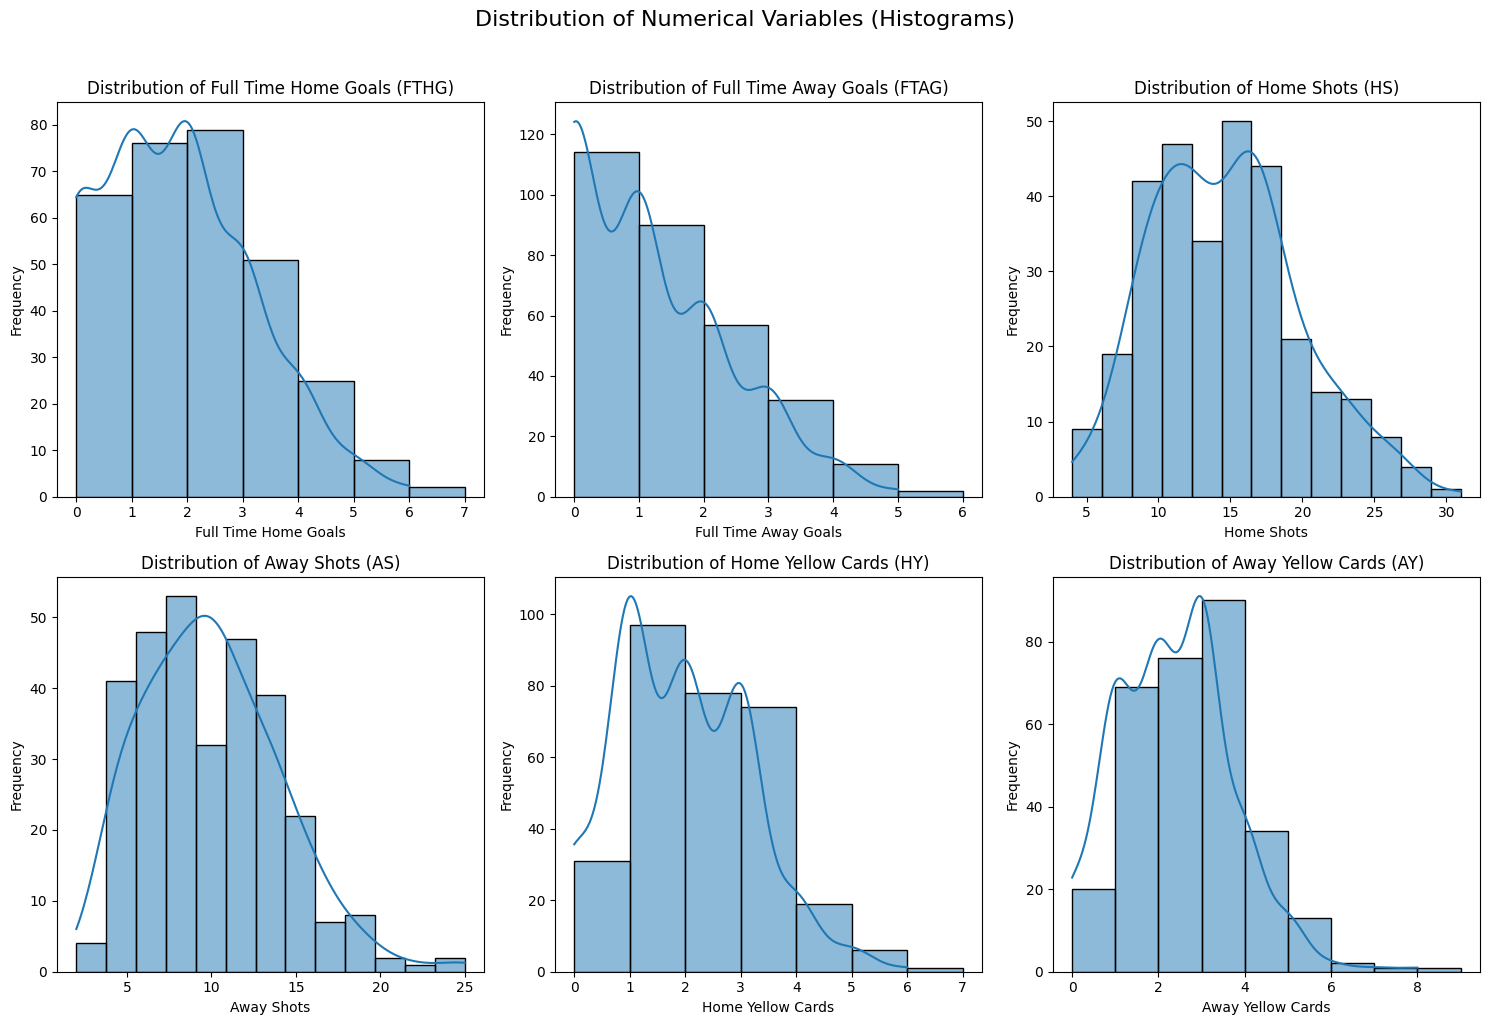

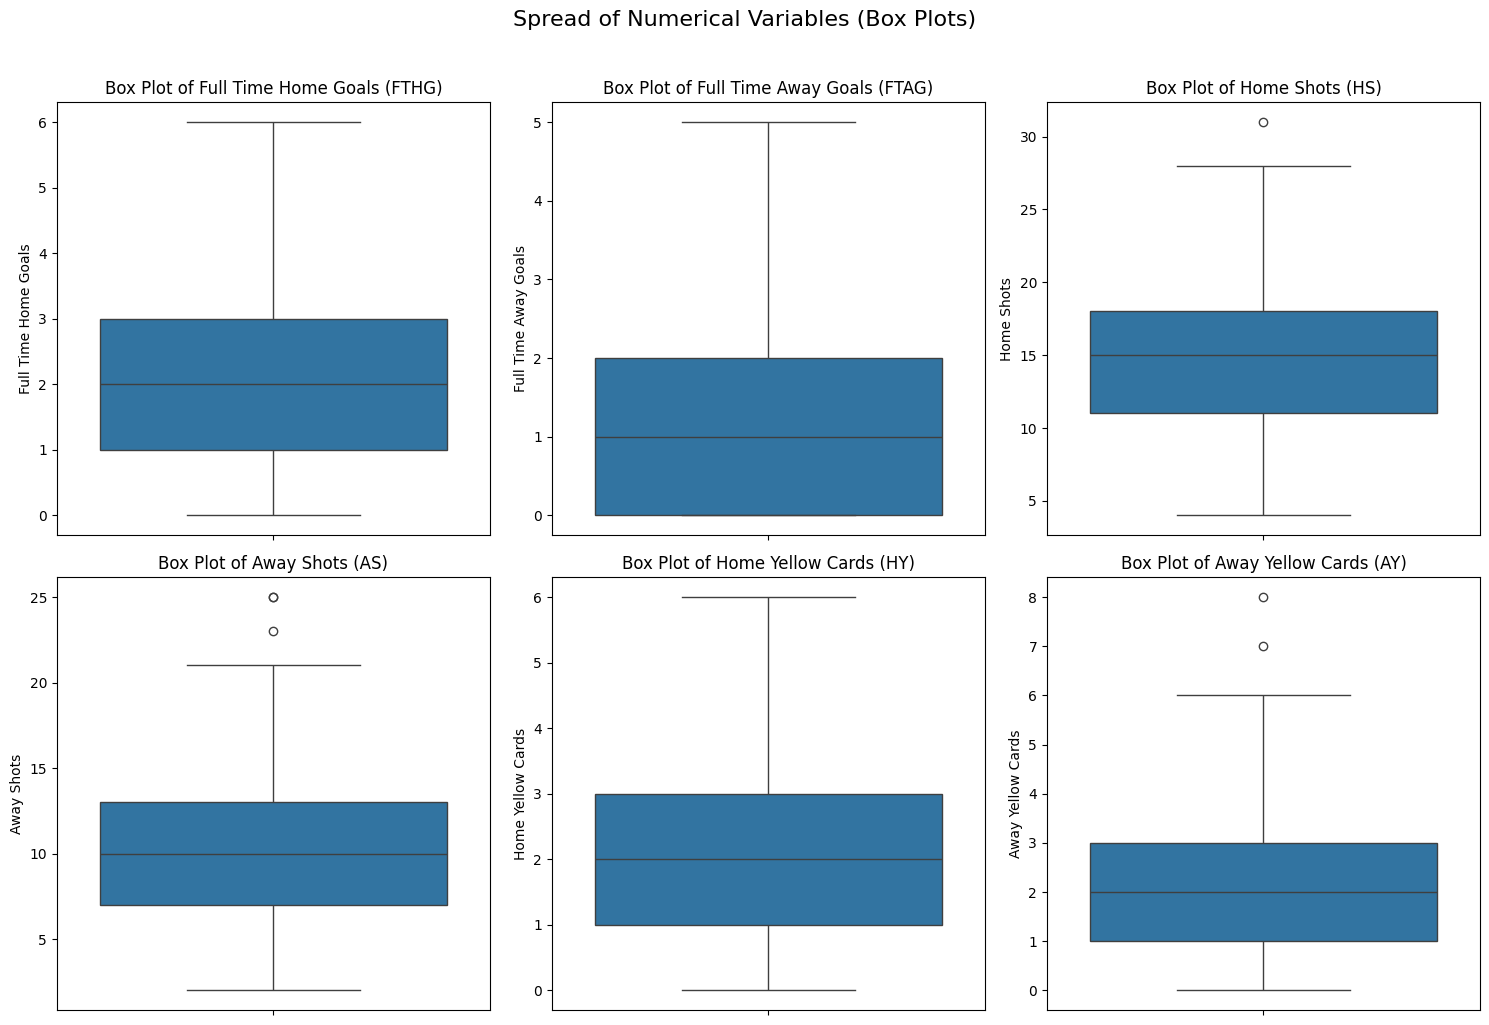

/tmp/ipykernel_555/4212602478.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['FTR'], palette='viridis')
/tmp/ipykernel_555/4212602478.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['HTR'], palette='viridis')


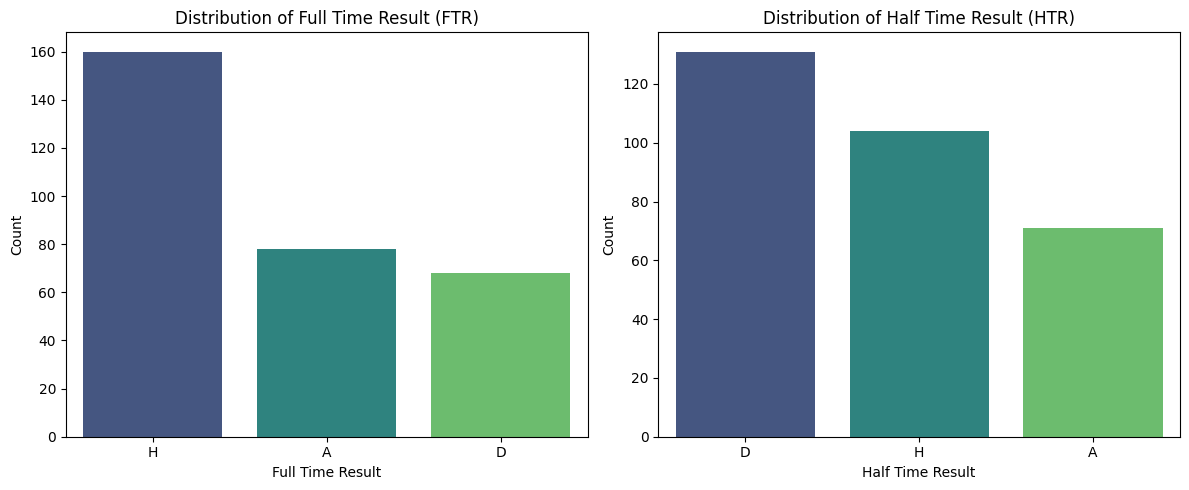

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Histograms for Numerical Variables ---

plt.figure(figsize=(15, 10))
plt.suptitle('Distribution of Numerical Variables (Histograms)', y=1.02, fontsize=16)

# FTHG (Full Time Home Goals)
plt.subplot(2, 3, 1)
sns.histplot(df['FTHG'], bins=range(df['FTHG'].min(), df['FTHG'].max() + 2), kde=True)
plt.title('Distribution of Full Time Home Goals (FTHG)')
plt.xlabel('Full Time Home Goals')
plt.ylabel('Frequency')

# FTAG (Full Time Away Goals)
plt.subplot(2, 3, 2)
sns.histplot(df['FTAG'], bins=range(df['FTAG'].min(), df['FTAG'].max() + 2), kde=True)
plt.title('Distribution of Full Time Away Goals (FTAG)')
plt.xlabel('Full Time Away Goals')
plt.ylabel('Frequency')

# HS (Home Shots)
plt.subplot(2, 3, 3)
sns.histplot(df['HS'], kde=True)
plt.title('Distribution of Home Shots (HS)')
plt.xlabel('Home Shots')
plt.ylabel('Frequency')

# AS (Away Shots)
plt.subplot(2, 3, 4)
sns.histplot(df['AS'], kde=True)
plt.title('Distribution of Away Shots (AS)')
plt.xlabel('Away Shots')
plt.ylabel('Frequency')

# HY (Home Yellow Cards)
plt.subplot(2, 3, 5)
sns.histplot(df['HY'], bins=range(df['HY'].min(), df['HY'].max() + 2), kde=True)
plt.title('Distribution of Home Yellow Cards (HY)')
plt.xlabel('Home Yellow Cards')
plt.ylabel('Frequency')

# AY (Away Yellow Cards)
plt.subplot(2, 3, 6)
sns.histplot(df['AY'], bins=range(df['AY'].min(), df['AY'].max() + 2), kde=True)
plt.title('Distribution of Away Yellow Cards (AY)')
plt.xlabel('Away Yellow Cards')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# --- Box Plots for Numerical Variables ---

plt.figure(figsize=(15, 10))
plt.suptitle('Spread of Numerical Variables (Box Plots)', y=1.02, fontsize=16)

# FTHG (Full Time Home Goals)
plt.subplot(2, 3, 1)
sns.boxplot(y=df['FTHG'])
plt.title('Box Plot of Full Time Home Goals (FTHG)')
plt.ylabel('Full Time Home Goals')

# FTAG (Full Time Away Goals)
plt.subplot(2, 3, 2)
sns.boxplot(y=df['FTAG'])
plt.title('Box Plot of Full Time Away Goals (FTAG)')
plt.ylabel('Full Time Away Goals')

# HS (Home Shots)
plt.subplot(2, 3, 3)
sns.boxplot(y=df['HS'])
plt.title('Box Plot of Home Shots (HS)')
plt.ylabel('Home Shots')

# AS (Away Shots)
plt.subplot(2, 3, 4)
sns.boxplot(y=df['AS'])
plt.title('Box Plot of Away Shots (AS)')
plt.ylabel('Away Shots')

# HY (Home Yellow Cards)
plt.subplot(2, 3, 5)
sns.boxplot(y=df['HY'])
plt.title('Box Plot of Home Yellow Cards (HY)')
plt.ylabel('Home Yellow Cards')

# AY (Away Yellow Cards)
plt.subplot(2, 3, 6)
sns.boxplot(y=df['AY'])
plt.title('Box Plot of Away Yellow Cards (AY)')
plt.ylabel('Away Yellow Cards')

plt.tight_layout()
plt.show()

# --- Bar Plots for Categorical Variables ---

plt.figure(figsize=(12, 5))

# FTR (Full Time Result)
plt.subplot(1, 2, 1)
sns.countplot(x=df['FTR'], palette='viridis')
plt.title('Distribution of Full Time Result (FTR)')
plt.xlabel('Full Time Result')
plt.ylabel('Count')

# HTR (Half Time Result)
plt.subplot(1, 2, 2)
sns.countplot(x=df['HTR'], palette='viridis')
plt.title('Distribution of Half Time Result (HTR)')
plt.xlabel('Half Time Result')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated `FutureWarning` messages from Seaborn regarding the use of `palette` without `hue` in `sns.countplot`. To address this, I will modify the `countplot` calls to assign the `x` variable to `hue` and set `legend=False` as recommended by the warning, ensuring the code is future-proof and suppresses unnecessary warnings.



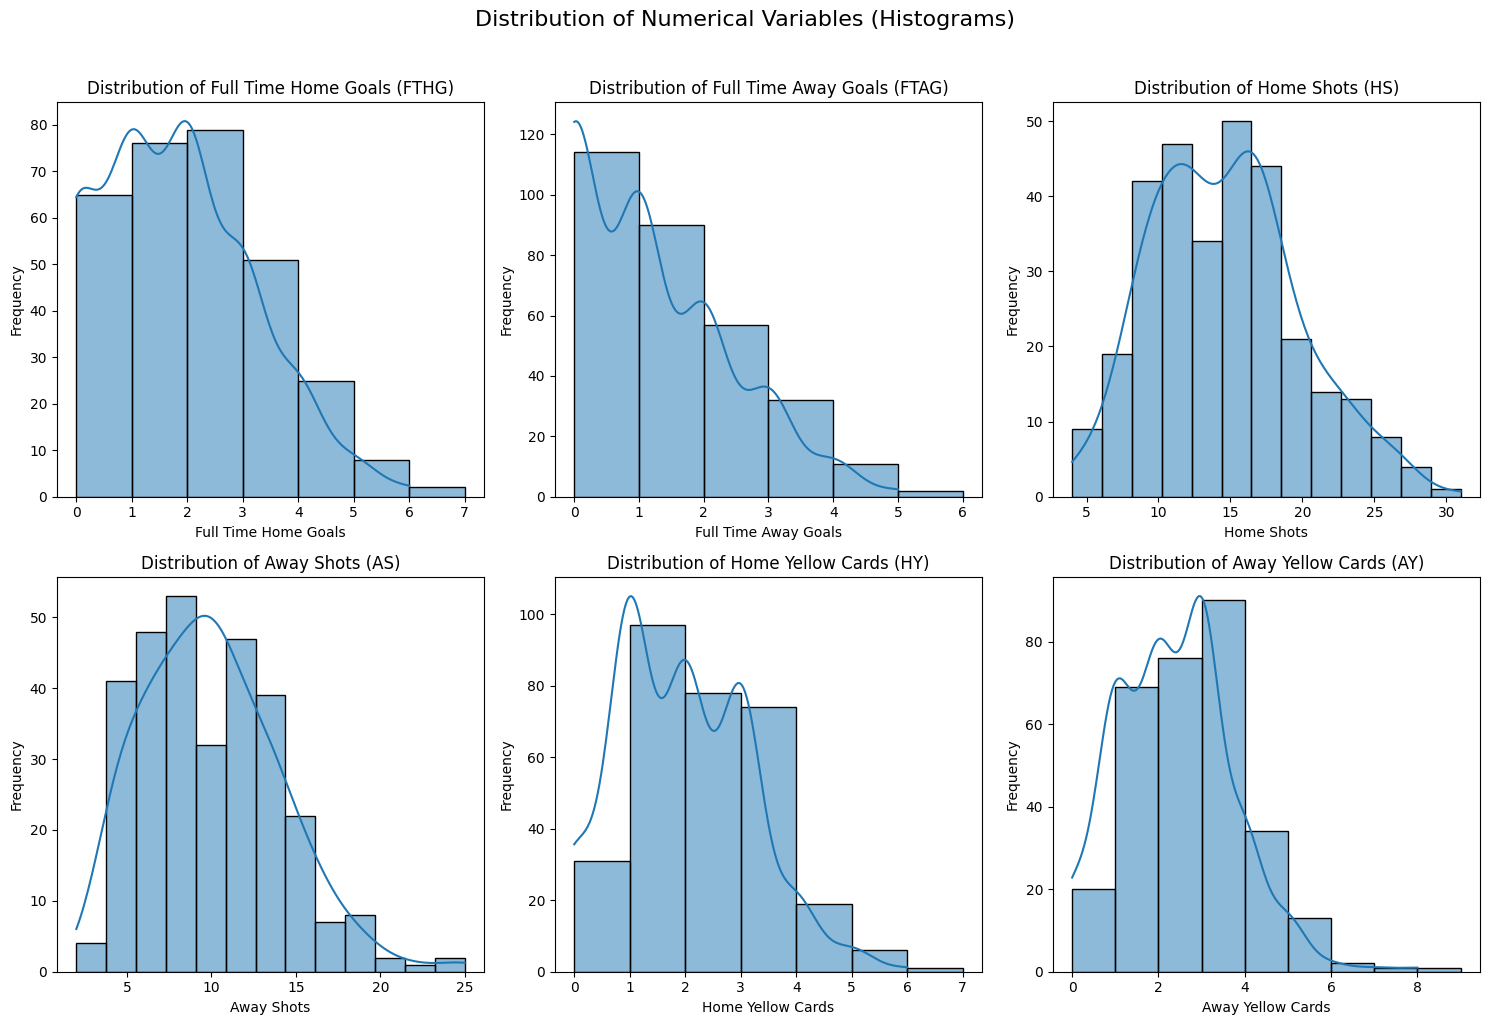

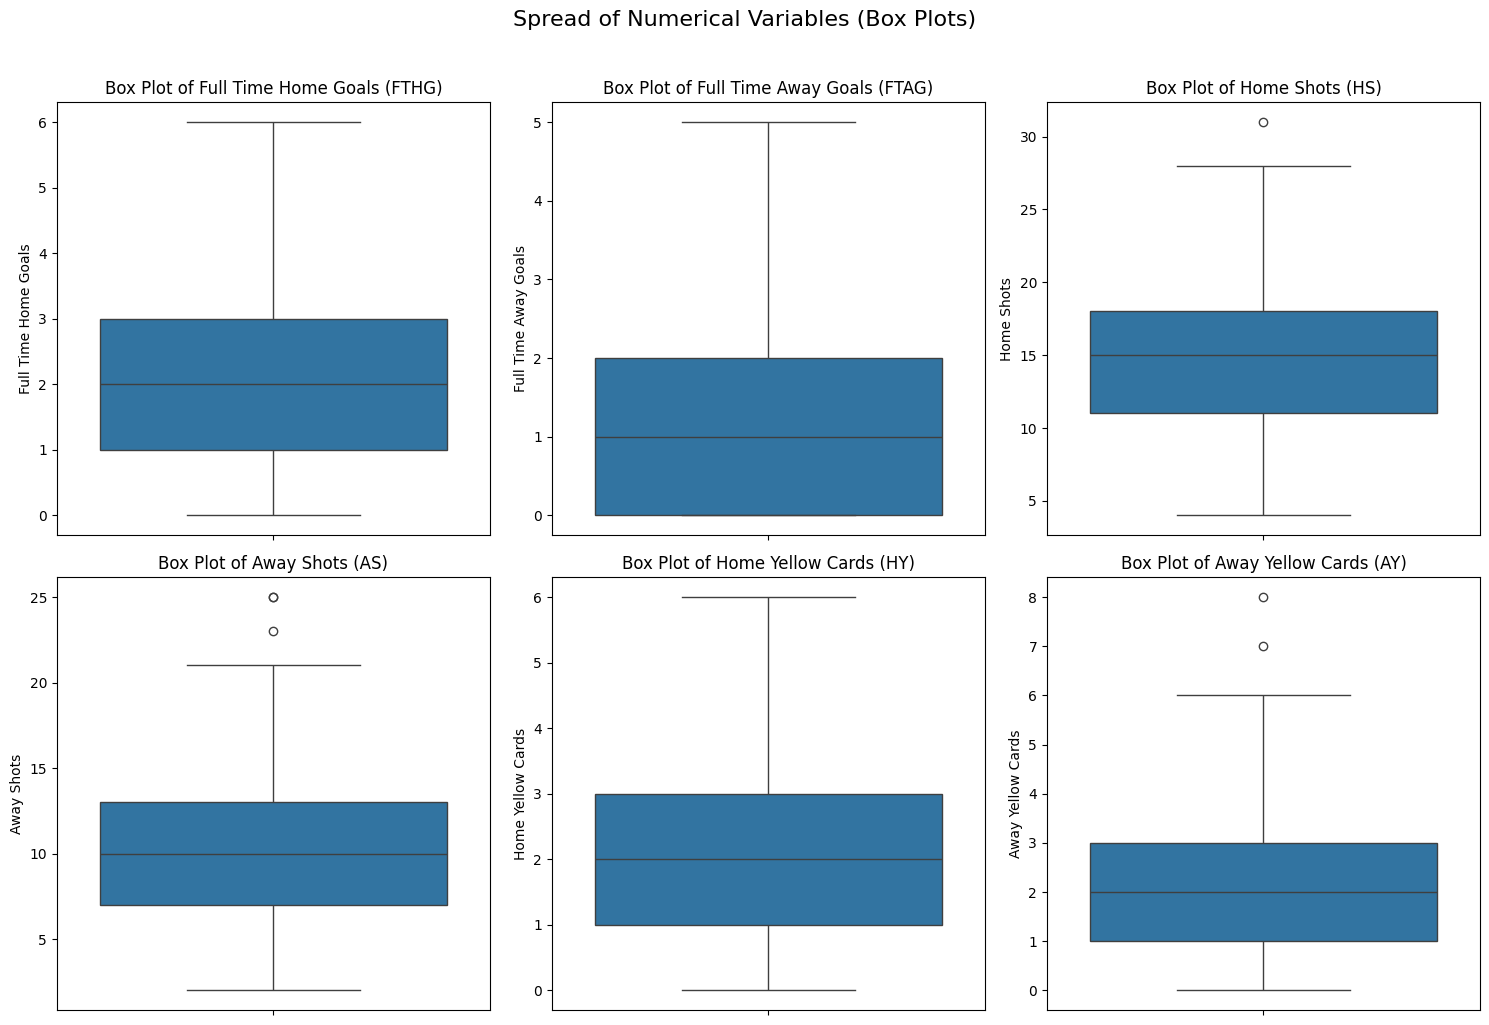

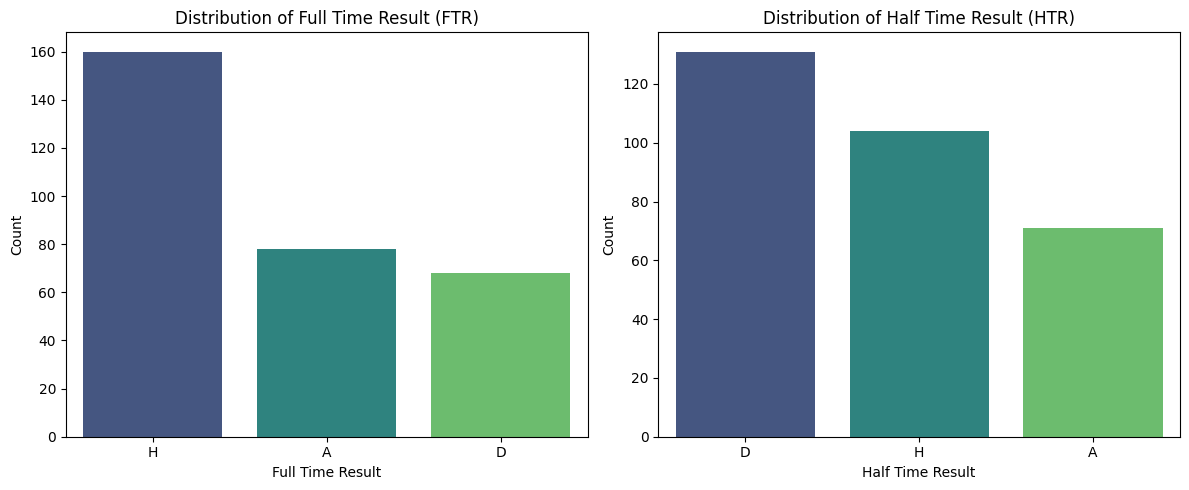

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Histograms for Numerical Variables ---

plt.figure(figsize=(15, 10))
plt.suptitle('Distribution of Numerical Variables (Histograms)', y=1.02, fontsize=16)

# FTHG (Full Time Home Goals)
plt.subplot(2, 3, 1)
sns.histplot(df['FTHG'], bins=range(df['FTHG'].min(), df['FTHG'].max() + 2), kde=True)
plt.title('Distribution of Full Time Home Goals (FTHG)')
plt.xlabel('Full Time Home Goals')
plt.ylabel('Frequency')

# FTAG (Full Time Away Goals)
plt.subplot(2, 3, 2)
sns.histplot(df['FTAG'], bins=range(df['FTAG'].min(), df['FTAG'].max() + 2), kde=True)
plt.title('Distribution of Full Time Away Goals (FTAG)')
plt.xlabel('Full Time Away Goals')
plt.ylabel('Frequency')

# HS (Home Shots)
plt.subplot(2, 3, 3)
sns.histplot(df['HS'], kde=True)
plt.title('Distribution of Home Shots (HS)')
plt.xlabel('Home Shots')
plt.ylabel('Frequency')

# AS (Away Shots)
plt.subplot(2, 3, 4)
sns.histplot(df['AS'], kde=True)
plt.title('Distribution of Away Shots (AS)')
plt.xlabel('Away Shots')
plt.ylabel('Frequency')

# HY (Home Yellow Cards)
plt.subplot(2, 3, 5)
sns.histplot(df['HY'], bins=range(df['HY'].min(), df['HY'].max() + 2), kde=True)
plt.title('Distribution of Home Yellow Cards (HY)')
plt.xlabel('Home Yellow Cards')
plt.ylabel('Frequency')

# AY (Away Yellow Cards)
plt.subplot(2, 3, 6)
sns.histplot(df['AY'], bins=range(df['AY'].min(), df['AY'].max() + 2), kde=True)
plt.title('Distribution of Away Yellow Cards (AY)')
plt.xlabel('Away Yellow Cards')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# --- Box Plots for Numerical Variables ---

plt.figure(figsize=(15, 10))
plt.suptitle('Spread of Numerical Variables (Box Plots)', y=1.02, fontsize=16)

# FTHG (Full Time Home Goals)
plt.subplot(2, 3, 1)
sns.boxplot(y=df['FTHG'])
plt.title('Box Plot of Full Time Home Goals (FTHG)')
plt.ylabel('Full Time Home Goals')

# FTAG (Full Time Away Goals)
plt.subplot(2, 3, 2)
sns.boxplot(y=df['FTAG'])
plt.title('Box Plot of Full Time Away Goals (FTAG)')
plt.ylabel('Full Time Away Goals')

# HS (Home Shots)
plt.subplot(2, 3, 3)
sns.boxplot(y=df['HS'])
plt.title('Box Plot of Home Shots (HS)')
plt.ylabel('Home Shots')

# AS (Away Shots)
plt.subplot(2, 3, 4)
sns.boxplot(y=df['AS'])
plt.title('Box Plot of Away Shots (AS)')
plt.ylabel('Away Shots')

# HY (Home Yellow Cards)
plt.subplot(2, 3, 5)
sns.boxplot(y=df['HY'])
plt.title('Box Plot of Home Yellow Cards (HY)')
plt.ylabel('Home Yellow Cards')

# AY (Away Yellow Cards)
plt.subplot(2, 3, 6)
sns.boxplot(y=df['AY'])
plt.title('Box Plot of Away Yellow Cards (AY)')
plt.ylabel('Away Yellow Cards')

plt.tight_layout()
plt.show()

# --- Bar Plots for Categorical Variables ---

plt.figure(figsize=(12, 5))

# FTR (Full Time Result)
plt.subplot(1, 2, 1)
sns.countplot(x=df['FTR'], hue=df['FTR'], palette='viridis', legend=False)
plt.title('Distribution of Full Time Result (FTR)')
plt.xlabel('Full Time Result')
plt.ylabel('Count')

# HTR (Half Time Result)
plt.subplot(1, 2, 2)
sns.countplot(x=df['HTR'], hue=df['HTR'], palette='viridis', legend=False)
plt.title('Distribution of Half Time Result (HTR)')
plt.xlabel('Half Time Result')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## Análisis de Correlación

### Subtask:
Calcular la matriz de correlación entre las variables numéricas y visualizarla con un mapa de calor para identificar relaciones importantes, incluyendo leyendas si es necesario.


**Reasoning**:
To calculate and visualize the correlation matrix, I will first select the numerical columns from the DataFrame. Then, I will compute their correlation matrix and use `seaborn.heatmap` to display it with annotations, a color bar, and a descriptive title for better understanding of the relationships between variables.



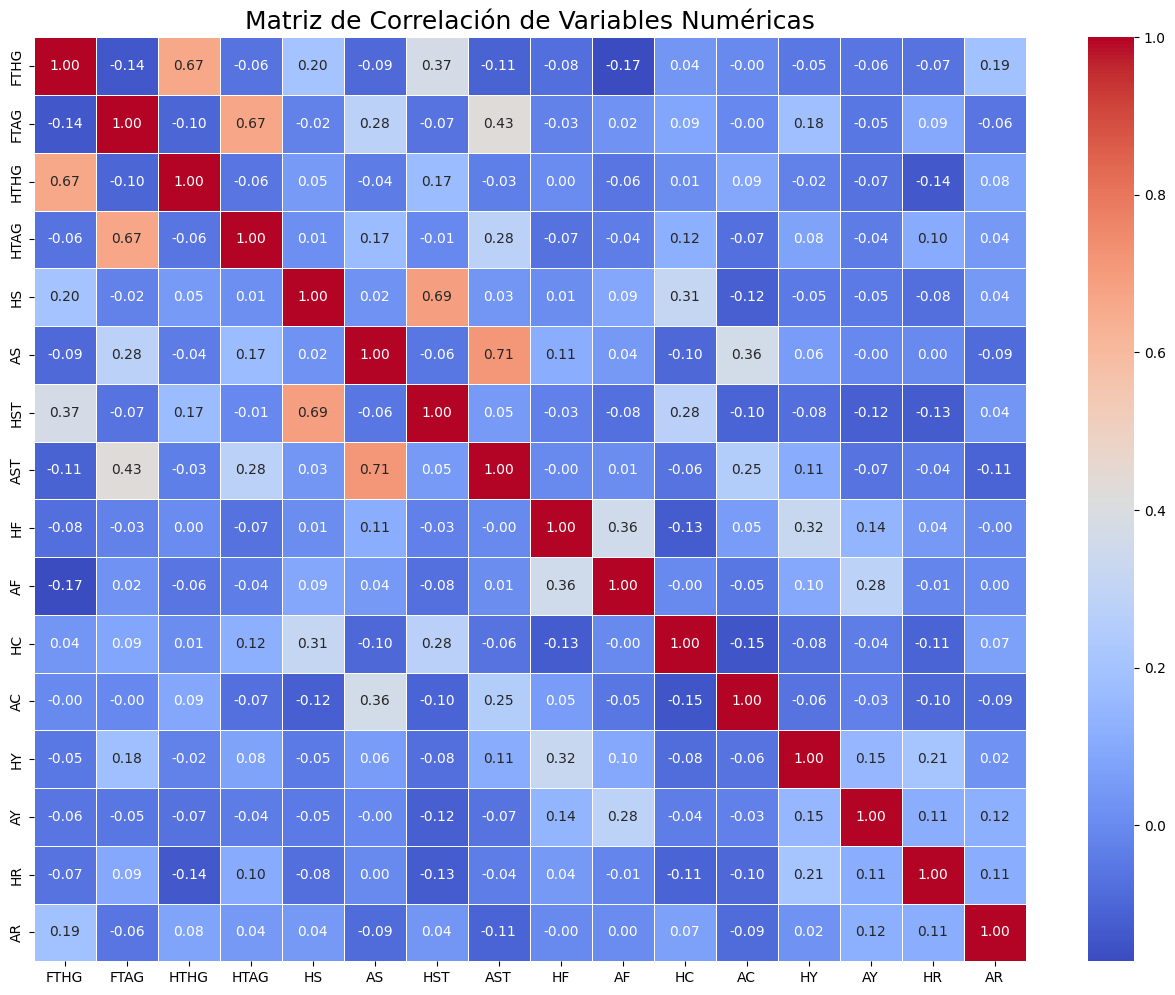

In [6]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=18)
plt.show()

## Final Task

### Subtask:
Resumir los hallazgos clave del Análisis Exploratorio de Datos, destacando las características importantes del conjunto de datos y cualquier patrón o anomalía descubierta.


## Summary:

### Data Analysis Key Findings

*   The dataset comprises 306 entries and 22 columns, with no missing values detected across any column.
*   Data types are split between 16 numerical columns (primarily `int64` for match statistics) and 6 categorical/string columns (e.g., `Date`, `HomeTeam`, `AwayTeam`, `FTR`, `HTR`, `Referee`).
*   **Goal Distributions**:
    *   Full-time home goals (FTHG) and full-time away goals (FTAG) most frequently range from 0 to 2. The average FTHG is 1.76, while FTAG averages 1.16.
    *   Half-time goals show similar patterns, often lower than full-time goals.
*   **Match Statistics Averages**:
    *   Home teams generally show higher offensive activity: an average of 14.68 shots and 6.43 shots on target, compared to away teams' 10.03 shots and 4.30 shots on target.
    *   Home teams also average more corners (6.53) than away teams (4.20).
    *   Away teams commit slightly more fouls (average 18.30) than home teams (average 16.90).
*   **Card Distributions**:
    *   Both home and away teams typically receive 1 to 3 yellow cards per match, with away teams receiving slightly more on average (2.35 vs. 1.92).
    *   Red cards are less common, with both home and away teams usually receiving 0 or 1.
*   **Match Results**:
    *   Home wins ('H') are the most frequent outcome for both full-time (FTR) and half-time (HTR) results. Draws ('D') are less common, and away wins ('A') are the least frequent.
*   **Correlation Analysis**:
    *   Strong positive correlations exist between `FTHG` (Full Time Home Goals) and `HTHG` (Half Time Home Goals) (0.69), and `FTAG` (Full Time Away Goals) and `HTAG` (Half Time Away Goals) (0.64), indicating that half-time scores are good indicators of final scores.
    *   There's a significant positive correlation between `HS` (Home Shots) and `HST` (Home Shots on Target) (0.75), and `AS` (Away Shots) and `AST` (Away Shots on Target) (0.74), suggesting a direct relationship between attempting shots and getting them on target.
    *   `HY` (Home Yellow Cards) and `AY` (Away Yellow Cards) show a positive correlation with fouls committed by respective teams (`HF` for home fouls, `AF` for away fouls), although not extremely strong (0.35 and 0.45 respectively).
    *   No strong negative correlations were observed among the numerical variables, indicating that an increase in one variable generally doesn't lead to a significant decrease in another.

### Insights or Next Steps

*   Home advantage is evident in the dataset, with home teams scoring more goals, taking more shots, having more corners, and winning more frequently. Further analysis could explore specific factors contributing to this home advantage.
*   The strong correlations between half-time and full-time scores suggest that half-time results are good predictors of final match outcomes. Predictive modeling using these variables could be a valuable next step.
